# Лабораторная работа 2 — Raincloud plot

На данных [Beijing Multi-Site Air Quality](https://archive.ics.uci.edu/dataset/501/beijing%2Bmulti%2Bsite%2Bair%2Bquality%2Bdata) построим распределение **часовой температуры воздуха** на станции Aotizhongxin по сезонам. Локальный ZIP-архив берётся из `../lab_1/`; скачивание не требуется.

Каждая строка графика — один сезон. Raincloud объединяет три представления: полупрозрачное «облако» плотности (KDE), boxplot и «дождь» из отдельных наблюдений с вертикальным jitter. Палитра повторяет `TSD/lab_1`.

## 1. Загрузка данных

В архиве 12 станций. Для сопоставимых групп берём одну станцию за весь доступный период, пропуски в `TEMP` исключаем. Сезон определяется по месяцу записи.

In [52]:
from pathlib import Path
from zipfile import ZipFile
import csv
import io

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
import numpy as np
import pandas as pd
from IPython.display import display

ARCHIVE_CANDIDATES = [
    Path("../lab_1/beijing_air_quality_uci.zip"),             # запуск из lab_2
    Path("3_course/TSD/lab_1/beijing_air_quality_uci.zip"),   # запуск из корня репозитория
]
archive_path = next((path for path in ARCHIVE_CANDIDATES if path.is_file()), None)
if archive_path is None:
    raise FileNotFoundError("Не найден архив beijing_air_quality_uci.zip в TSD/lab_1")

SEASONS = ["Зима", "Весна", "Лето", "Осень"]
MONTH_TO_SEASON = {
    12: "Зима", 1: "Зима", 2: "Зима",
    3: "Весна", 4: "Весна", 5: "Весна",
    6: "Лето", 7: "Лето", 8: "Лето",
    9: "Осень", 10: "Осень", 11: "Осень",
}
PALETTE = ["#F72585", "#7209B7", "#4361EE", "#00B4D8"]
BOX_COLOR = "#14213D"
MEDIAN_COLOR = "#FF9F1C"
JITTER_SEED = 2026
MAX_DOTS_PER_SEASON = 900
KDE_MAX_POINTS = 20_000  # KDE по подвыборке, boxplot по всем данным
DENSITY_LINEWIDTH = 2.8  # толщина контура облака и линий KDE
SCATTER_GAP = 0.04  # расстояние точек от основания облака
SCATTER_JITTER_SPAN = 0.07  # ширина полосы точек
BOX_BELOW_OFFSET = 0.25  # положение boxplot после полосы точек
LAYER_PANEL_GAP = 0.035  # расстояние между панелями раздела 6
LAYER_SCATTER_GAP = 0.10  # зазор между соседними scatter-панелями в разделе 6
LAYER_BOX_GAP = 0.10  # зазор между соседними boxplot-панелями в разделе 6
POINT_ALPHA = None  # None: автоматически; 0..1: фиксированная прозрачность
ORIENTATION = "horizontal"  # "horizontal" или "vertical" (поворот на 90°)

records = []
with ZipFile(archive_path) as archive:
    member = next(
        (name for name in archive.namelist()
         if name.endswith("PRSA_Data_Aotizhongxin_20130301-20170228.csv")),
        None,
    )
    if member is None:
        raise FileNotFoundError("В архиве нет CSV станции Aotizhongxin")
    with archive.open(member) as stream:
        reader = csv.DictReader(io.TextIOWrapper(stream, encoding="utf-8"))
        for row in reader:
            raw_temp = row["TEMP"].strip()
            if raw_temp and raw_temp.upper() != "NA":
                records.append({
                    "Сезон": MONTH_TO_SEASON[int(row["month"])],
                    "Температура, °C": float(raw_temp),
                })

data = pd.DataFrame.from_records(records)
data["Сезон"] = pd.Categorical(data["Сезон"], categories=SEASONS, ordered=True)
assert len(data) > 0 and data["Температура, °C"].notna().all()
print(f"Станция: Aotizhongxin; наблюдений с температурой: {len(data):,}")
display(data.head())

Станция: Aotizhongxin; наблюдений с температурой: 35,044


,Сезон,"Температура, °C"
0,Весна,-0.7
1,Весна,-1.1
2,Весна,-1.1
3,Весна,-1.4
4,Весна,-2.0


## 2. Числовая сводка

График ниже использует **все** наблюдения для KDE и boxplot. Чтобы точки оставались различимыми, для «дождя» случайно выбирается не более 900 записей на сезон с фиксированным seed.

In [53]:
temperature = data.groupby("Сезон", observed=True)["Температура, °C"]
summary = temperature.agg(
    n="count",
    minimum="min",
    q1=lambda values: values.quantile(0.25),
    median="median",
    q3=lambda values: values.quantile(0.75),
    maximum="max",
)
summary["IQR"] = summary["q3"] - summary["q1"]
display(summary.round(1))

,n,minimum,q1,median,q3,maximum,IQR
Сезон,,,,,,,
Зима,8651,-16.8,-3.3,-0.3,2.7,15.9,6.0
Весна,8832,-7.3,9.2,15.2,21.0,40.5,11.8
Лето,8832,13.8,22.9,26.0,29.5,38.8,6.6
Осень,8729,-9.7,6.8,13.7,19.3,33.6,12.5


## 3. Raincloud plot

Цвета взяты из lab_1. Настройки в первой кодовой ячейке:

- ORIENTATION поворачивает все графики на 90°;
- POINT_ALPHA = None включает автоматическую прозрачность точек, число от 0 до 1 задаёт её вручную;
- DENSITY_LINEWIDTH задаёт толщину контуров плотности;
- SCATTER_GAP сдвигает точки к облаку или от него, SCATTER_JITTER_SPAN меняет толщину полосы точек;
- BOX_BELOW_OFFSET задаёт положение boxplot во втором варианте;
- LAYER_PANEL_GAP меняет промежутки между панелями раздела 6.

После изменения настройки нужно повторно выполнить ячейки с графиками.

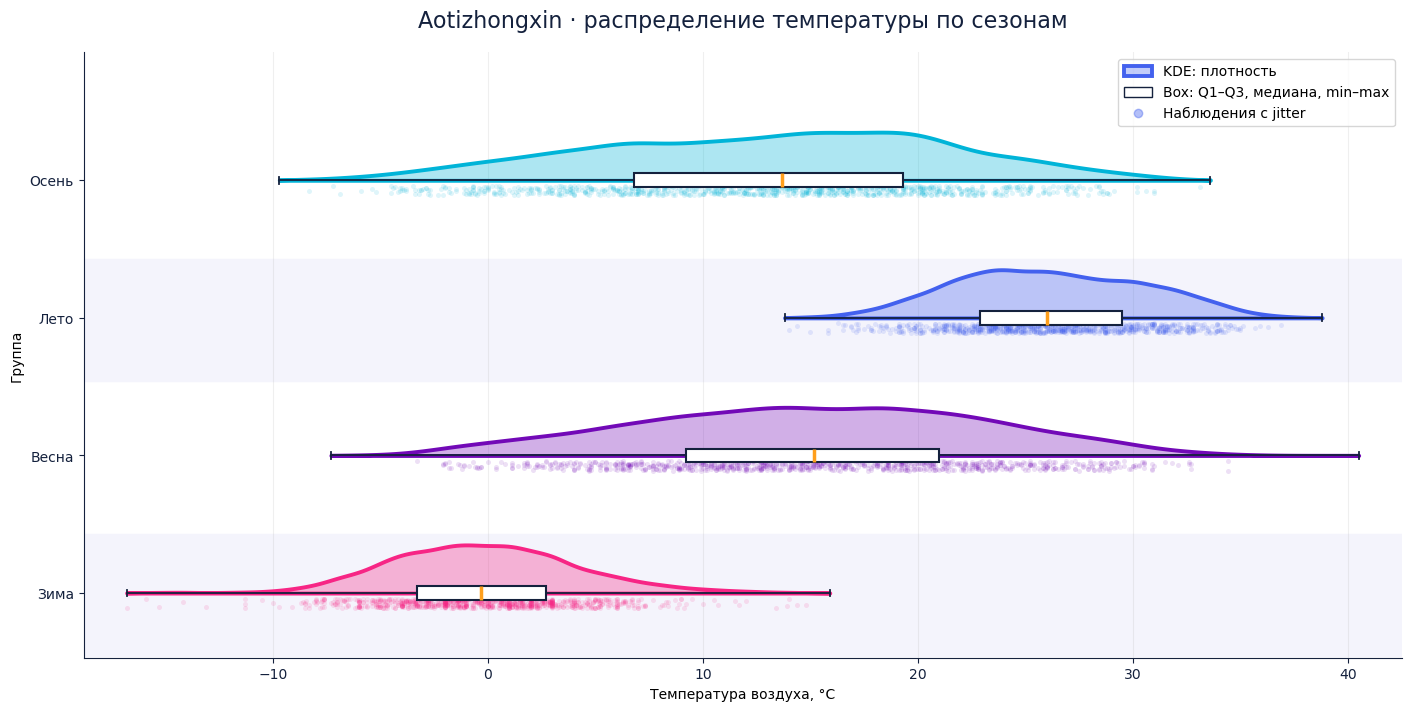

In [54]:
plt.rcParams["font.family"] = "DejaVu Sans"
VALUE_LIMITS = (
    data["Температура, °C"].min() - 2,
    data["Температура, °C"].max() + 2,
)


def point_alpha(n_drawn):
    if POINT_ALPHA is not None:
        if not 0 <= POINT_ALPHA <= 1:
            raise ValueError("POINT_ALPHA должен быть в диапазоне [0, 1]")
        return float(POINT_ALPHA)
    return float(np.clip(0.90 * (25 / max(n_drawn, 1)) ** 0.55, 0.001, 0.92))


def plot_raincloud_groups(groups, labels, colors, box_below=False,
                          orientation=ORIENTATION, title=None,
                          max_dots_per_group=MAX_DOTS_PER_SEASON):
    if orientation not in ("horizontal", "vertical"):
        raise ValueError("ORIENTATION: horizontal или vertical")
    if not (len(groups) == len(labels) == len(colors)):
        raise ValueError("Группы, подписи и цвета должны иметь одинаковую длину")
    horizontal = orientation == "horizontal"
    positions = np.arange(len(labels))
    fig, ax = plt.subplots(
        figsize=(14, 7) if horizontal else (9, 10),
        layout="constrained",
    )
    rng = np.random.default_rng(JITTER_SEED)

    for pos, (values, color) in enumerate(zip(groups, colors)):
        values = np.asarray(values, dtype=float)
        if len(values) == 0:
            raise ValueError(f"Пустая группа: {labels[pos]}")
        if pos % 2 == 0:
            if horizontal:
                ax.axhspan(pos - 0.46, pos + 0.43, color="#f4f4fc", zorder=0)
            else:
                ax.axvspan(pos - 0.46, pos + 0.43, color="#f4f4fc", zorder=0)

        if len(values) >= 2 and np.std(values) > 0:
            density_values = (
                values if len(values) <= KDE_MAX_POINTS else
                rng.choice(values, size=KDE_MAX_POINTS, replace=False)
            )
            violin = ax.violinplot(
                [density_values], positions=[pos], vert=not horizontal,
                widths=0.70, points=180, showextrema=False,
                showmeans=False, showmedians=False,
            )
            body = violin["bodies"][0]
            vertices = body.get_paths()[0].vertices
            coordinate = 1 if horizontal else 0
            vertices[:, coordinate] = np.maximum(vertices[:, coordinate], pos)
            body.set_facecolor(to_rgba(color, 0.32))
            body.set_edgecolor(color)
            body.set_alpha(None)
            body.set_linewidth(DENSITY_LINEWIDTH)
            body.set_zorder(2)

        sample = (
            values if len(values) <= max_dots_per_group else
            rng.choice(values, size=max_dots_per_group, replace=False)
        )
        jitter = pos - SCATTER_GAP - rng.uniform(
            0, SCATTER_JITTER_SPAN, size=len(sample)
        )
        if horizontal:
            ax.scatter(
                sample, jitter, s=13, color=color,
                alpha=point_alpha(len(sample)), linewidths=0, zorder=3,
                rasterized=True,
            )
        else:
            ax.scatter(
                jitter, sample, s=13, color=color,
                alpha=point_alpha(len(sample)), linewidths=0, zorder=3,
                rasterized=True,
            )

        box_position = pos - BOX_BELOW_OFFSET if box_below else pos
        parts = ax.boxplot(
            [values], positions=[box_position], vert=not horizontal,
            widths=0.10, whis=(0, 100), showfliers=False,
            patch_artist=True, manage_ticks=False,
            boxprops={"facecolor": "white", "edgecolor": BOX_COLOR, "linewidth": 1.5},
            medianprops={"color": MEDIAN_COLOR, "linewidth": 2.5},
            whiskerprops={"color": BOX_COLOR, "linewidth": 1.3},
            capprops={"color": BOX_COLOR, "linewidth": 1.3},
        )
        for key in ("boxes", "medians", "whiskers", "caps"):
            for artist in parts[key]:
                artist.set_zorder(4)

    if horizontal:
        ax.set_yticks(positions, labels)
        ax.set_ylim(-0.47, len(labels) - 0.5 + 0.43)
        ax.set_xlim(*VALUE_LIMITS)
        ax.set_xlabel("Температура воздуха, °C")
        ax.set_ylabel("Группа")
        ax.grid(axis="x", alpha=0.20)
    else:
        ax.set_xticks(positions, labels)
        ax.set_xlim(-0.47, len(labels) - 0.5 + 0.43)
        ax.set_ylim(*VALUE_LIMITS)
        ax.set_xlabel("Группа")
        ax.set_ylabel("Температура воздуха, °C")
        ax.grid(axis="y", alpha=0.20)

    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(BOX_COLOR)
    ax.tick_params(colors=BOX_COLOR)
    ax.set_title(title or "Aotizhongxin · распределение температуры по сезонам",
                 fontsize=16, color=BOX_COLOR, pad=18)
    ax.legend(
        handles=[
            Patch(facecolor=to_rgba("#4361EE", 0.32), edgecolor="#4361EE",
                  linewidth=DENSITY_LINEWIDTH, label="KDE: плотность"),
            Patch(facecolor="white", edgecolor=BOX_COLOR,
                  label="Box: Q1–Q3, медиана, min–max"),
            Line2D([], [], linestyle="", marker="o", color="#4361EE",
                   alpha=max(point_alpha(max_dots_per_group), 0.4),
                   label="Наблюдения с jitter"),
        ],
        loc="upper right", frameon=True,
    )
    plt.show()


def plot_raincloud(frame, seasons=SEASONS, box_below=False,
                   orientation=ORIENTATION, title=None):
    groups = [
        frame.loc[frame["Сезон"] == season, "Температура, °C"].to_numpy()
        for season in seasons
    ]
    colors = [PALETTE[SEASONS.index(season)] for season in seasons]
    plot_raincloud_groups(
        groups, list(seasons), colors,
        box_below=box_below, orientation=orientation, title=title,
    )


plot_raincloud(data)

## 4. Отдельный вариант: boxplot после точек

Порядок элементов теперь такой: облако плотности, полоса точек сразу под ним, затем boxplot. Расстояние от облака до точек меняет SCATTER_GAP, толщину полосы — SCATTER_JITTER_SPAN. Положение нижнего boxplot задаёт BOX_BELOW_OFFSET. Эти параметры действуют и при вертикальной ориентации.

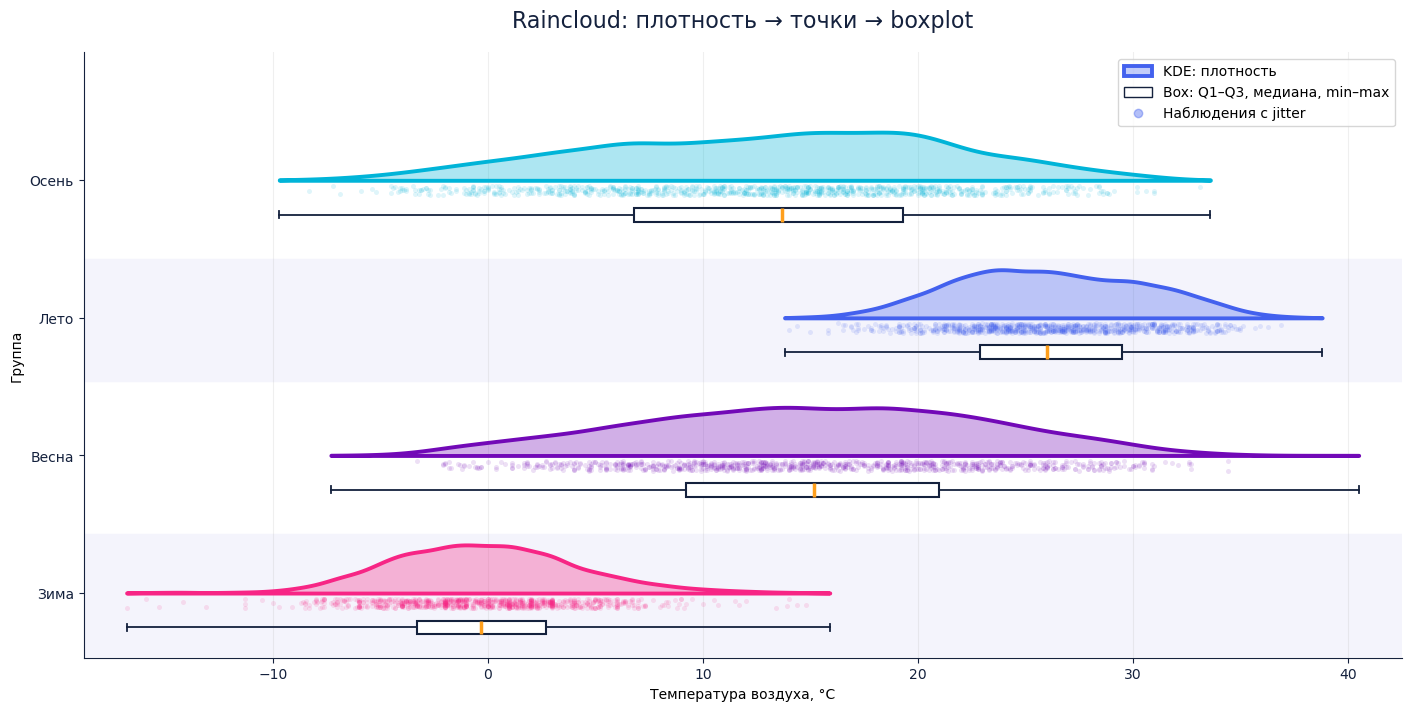

In [55]:
def plot_raincloud_box_below(frame, seasons=SEASONS, orientation=ORIENTATION,
                             title=None):
    plot_raincloud(
        frame, seasons=seasons, box_below=True, orientation=orientation,
        title=title or "Raincloud: плотность → точки → boxplot",
    )


plot_raincloud_box_below(data)

## 5. Тестовые датасеты по сезонам

Небольшие CSV содержат 10, 100 и 1000 строк всего либо **для каждого сезона**. Они сохранены в `test_data` и воспроизводимы. На рисунках для каждого сезона сравниваются 10, 100, 1000 и 1 000 000 точек.

Миллион точек создаётся прямо в памяти выборкой **с возвращением** из исходных температур данного сезона: в исходном наборе миллиона разных наблюдений на сезон нет. Большой CSV не сохраняется. На графике показаны все 1 000 000 точек; KDE ради скорости рассчитывается по 20 000 случайных значений, а boxplot — по полному миллиону. Прозрачность точек уменьшается автоматически.

На 10 точках форма KDE может заметно меняться от выбора наблюдений; это проверка отображения, а не точная оценка распределения.

In [56]:
TEST_SIZES = (10, 100, 1000)
TEST_SEED = 2042
test_dir = archive_path.resolve().parent.parent / "lab_2" / "test_data"
test_dir.mkdir(parents=True, exist_ok=True)

rng_test = np.random.default_rng(TEST_SEED)
indices_by_season = {
    season: rng_test.permutation(data.index[data["Сезон"] == season].to_numpy())
    for season in SEASONS
}

test_sets = {}
table_rows = []
for size in TEST_SIZES:
    base, remainder = divmod(size, len(SEASONS))
    counts = {
        season: base + (index < remainder)
        for index, season in enumerate(SEASONS)
    }
    chosen = np.concatenate([
        indices_by_season[season][:counts[season]] for season in SEASONS
    ])
    sample_frame = data.loc[chosen].copy().reset_index(drop=True)
    sample_frame["Сезон"] = pd.Categorical(
        sample_frame["Сезон"], categories=SEASONS, ordered=True
    )
    assert len(sample_frame) == size
    test_sets[size] = sample_frame
    sample_frame.to_csv(test_dir / f"temperature_{size}.csv", index=False)
    table_rows.append({
        "Записей": size,
        **{season: counts[season] for season in SEASONS},
        "Прозрачность точек": round(point_alpha(min(counts.values())), 2),
    })

display(pd.DataFrame(table_rows))
print(f"Тестовые CSV: {test_dir}")

season_test_sets = {}
season_table = []
for size in TEST_SIZES:
    chosen = np.concatenate([
        indices_by_season[season][:size] for season in SEASONS
    ])
    sample_frame = data.loc[chosen].copy().reset_index(drop=True)
    sample_frame["Сезон"] = pd.Categorical(
        sample_frame["Сезон"], categories=SEASONS, ordered=True
    )
    assert len(sample_frame) == len(SEASONS) * size
    season_test_sets[size] = sample_frame
    sample_frame.to_csv(
        test_dir / f"temperature_per_season_{size}.csv", index=False
    )
    season_table.append({
        "Точек на сезон": size,
        "Всего строк": len(sample_frame),
        "Прозрачность": round(point_alpha(size), 2),
    })

display(pd.DataFrame(season_table))

,Записей,Зима,Весна,Лето,Осень,Прозрачность точек
0,10,3,3,2,2,0.92
1,100,25,25,25,25,0.90
2,1000,250,250,250,250,0.25


Тестовые CSV: /home/cyberpsychoz/NSU_studying-IIR/3_course/TSD/lab_2/test_data


,Точек на сезон,Всего строк,Прозрачность
0,10,40,0.92
1,100,400,0.42
2,1000,4000,0.12


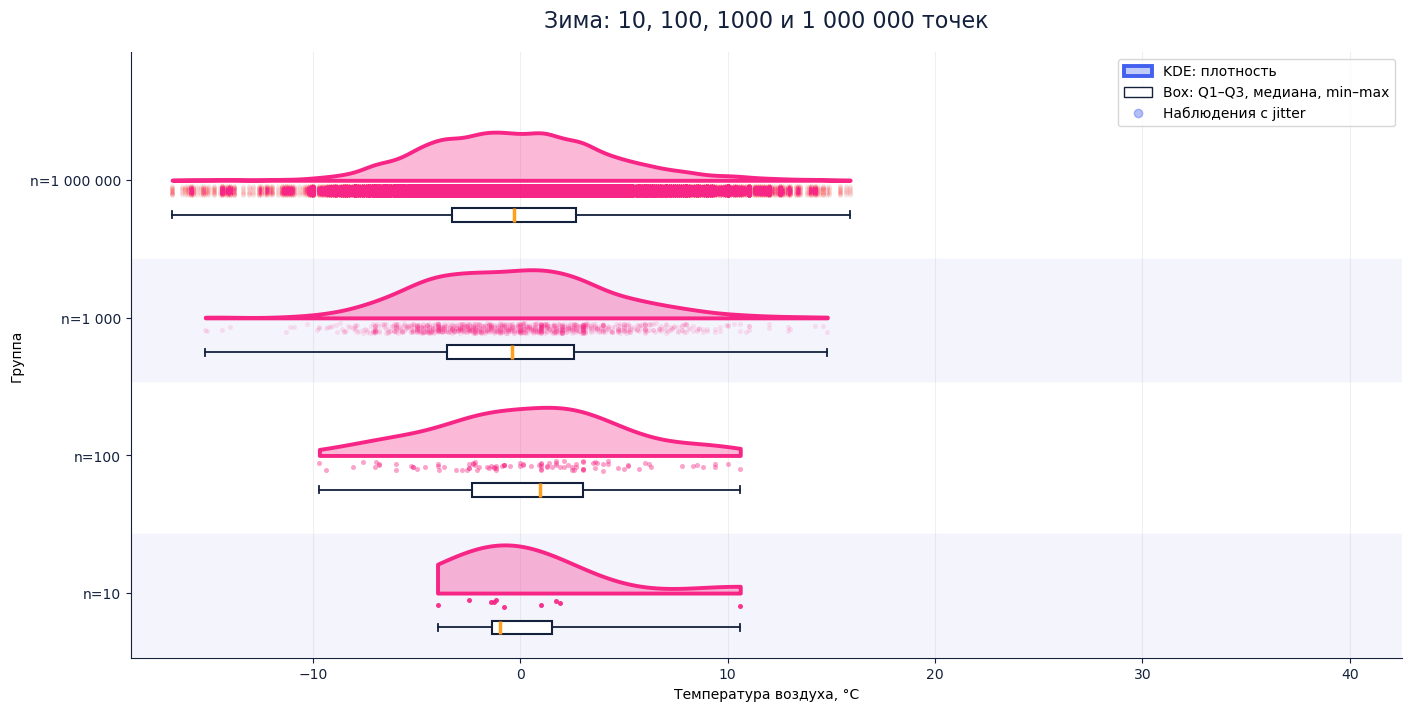

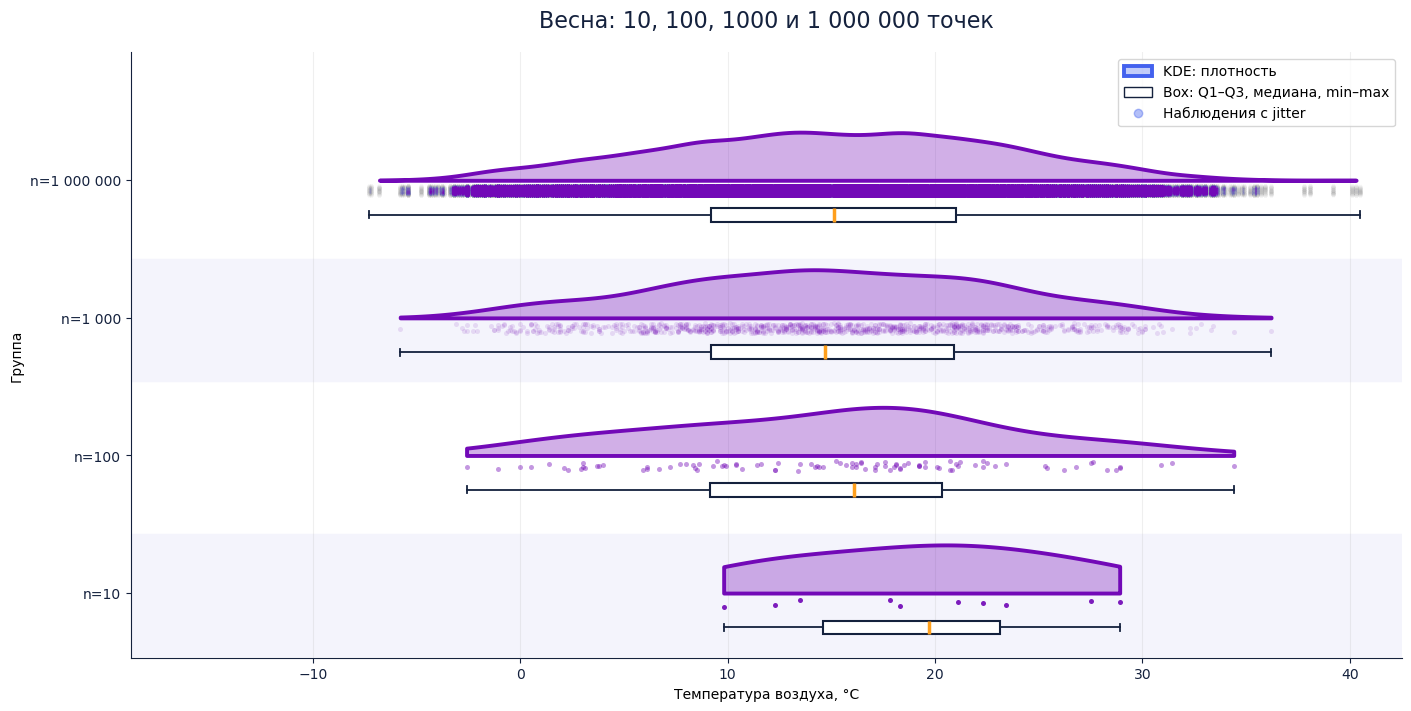

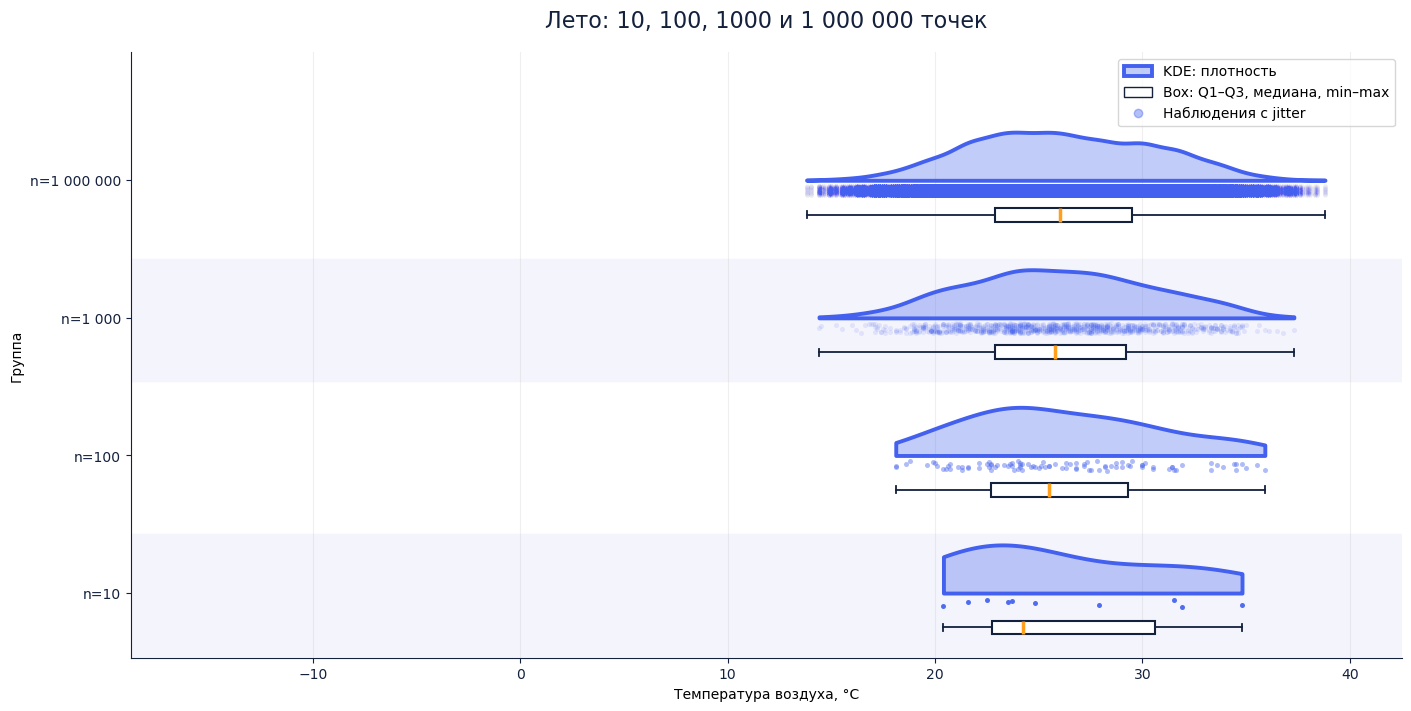

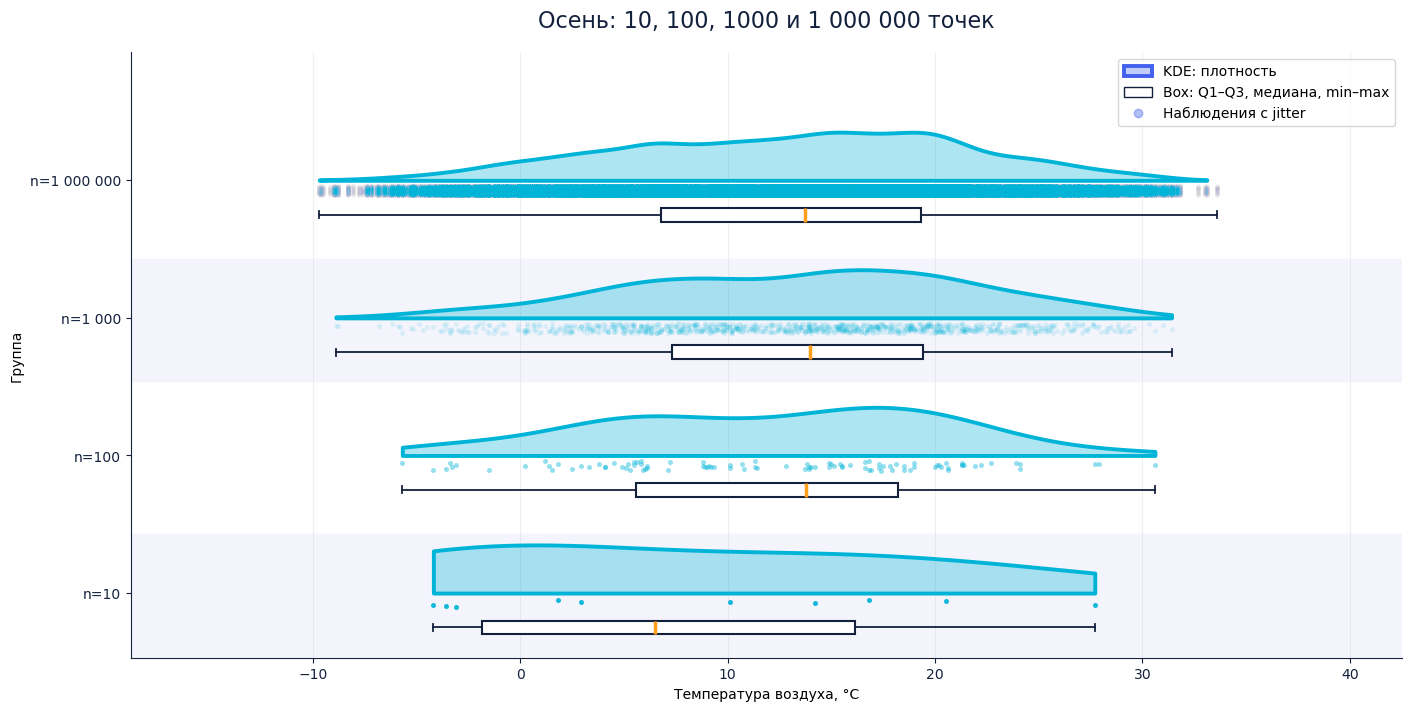

In [57]:
MILLION_POINTS = 1_000_000
rng_million = np.random.default_rng(TEST_SEED + 1)

for season in SEASONS:
    groups = [
        season_test_sets[size].loc[
            season_test_sets[size]["Сезон"] == season, "Температура, °C"
        ].to_numpy()
        for size in TEST_SIZES
    ]
    original_values = data.loc[
        data["Сезон"] == season, "Температура, °C"
    ].to_numpy()
    groups.append(rng_million.choice(original_values, size=MILLION_POINTS, replace=True))
    display_sizes = (*TEST_SIZES, MILLION_POINTS)
    color = PALETTE[SEASONS.index(season)]
    plot_raincloud_groups(
        groups,
        labels=[f"n={size:,}".replace(",", " ") for size in display_sizes],
        colors=[color] * len(display_sizes),
        box_below=True,
        orientation=ORIENTATION,
        title=f"{season}: 10, 100, 1000 и 1 000 000 точек",
        max_dots_per_group=MILLION_POINTS,
    )


## 6. Совмещённые плотности, затем точки и boxplot

На общей температурной шкале показаны плотности трёх сезонов, затем три полосы точек и три отдельных boxplot. В первой кодовой ячейке `LAYER_SCATTER_GAP` меняет **расстояние между соседними scatter-панелями**, а `LAYER_BOX_GAP` — между соседними boxplot-панелями. Например, `0.0` максимально сближает панели, `0.3` раздвигает их. `LAYER_PANEL_GAP` управляет двумя переходами между типами графиков: плотность → точки и точки → boxplot. Это работает и при `ORIENTATION = "vertical"`.


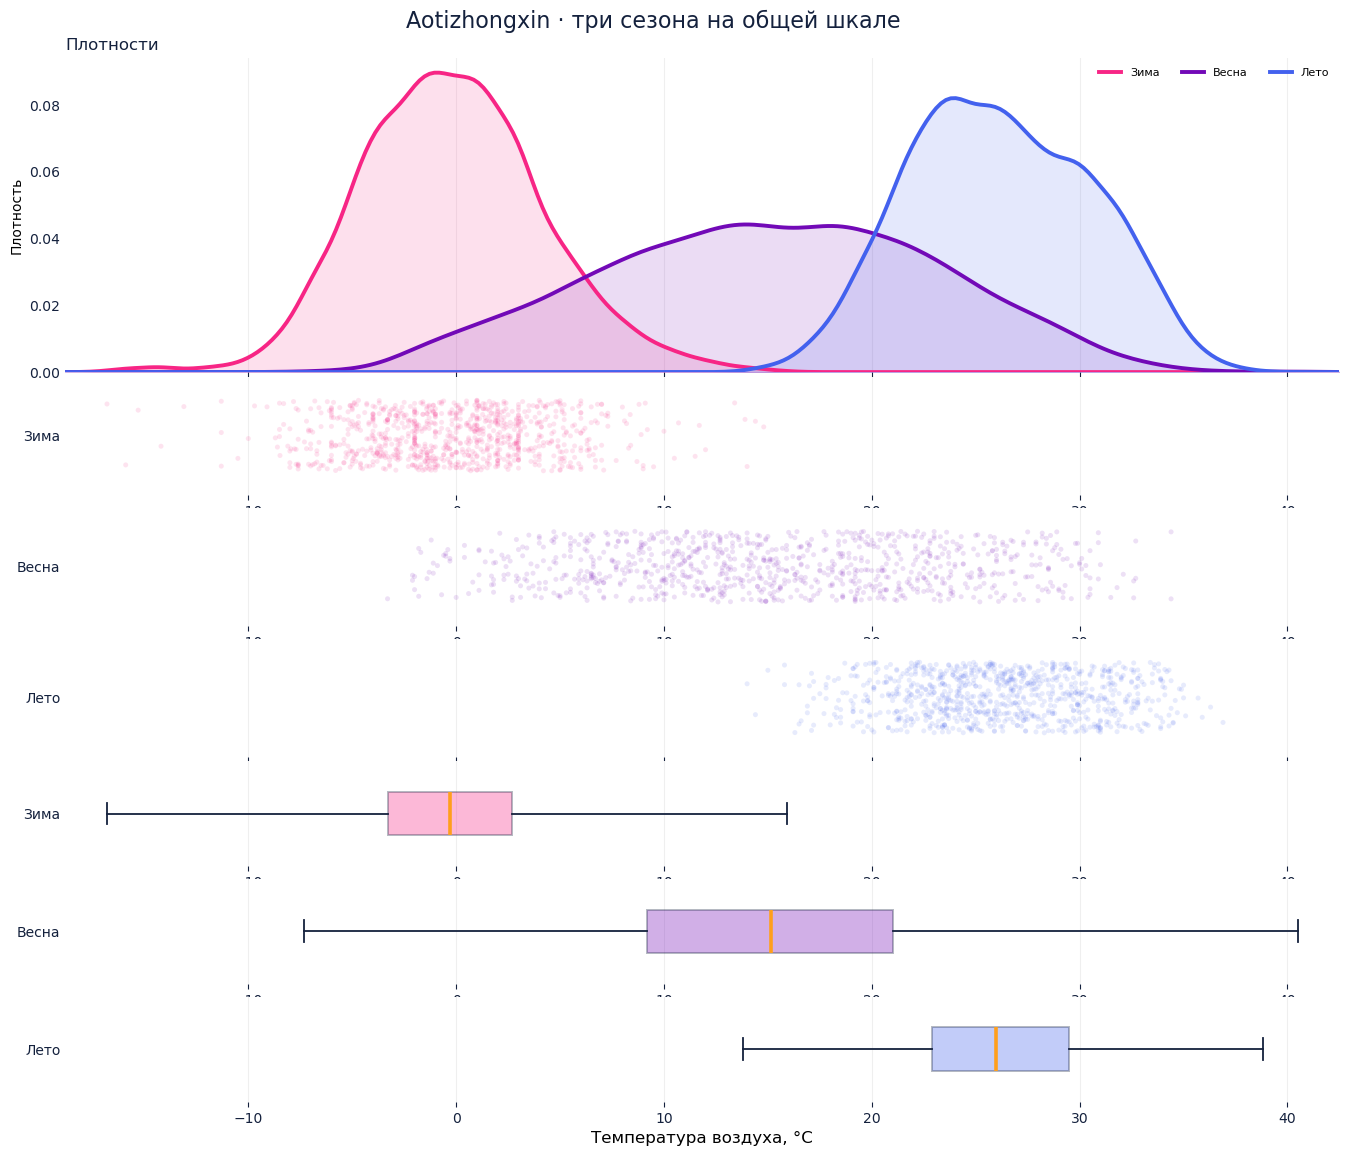

In [58]:
SELECTED_SEASONS = ("Зима", "Весна", "Лето")
if len(SELECTED_SEASONS) != 3 or any(s not in SEASONS for s in SELECTED_SEASONS):
    raise ValueError("Выберите ровно три сезона из SEASONS")


def gaussian_density(values, grid):
    bandwidth = max(
        1.06 * np.std(values, ddof=1) * len(values) ** (-1 / 5), 0.5
    )
    standardized = (grid[:, None] - values[None, :]) / bandwidth
    return np.exp(-0.5 * standardized**2).mean(axis=1) / (
        bandwidth * np.sqrt(2 * np.pi)
    )


def plot_layered(frame, seasons=SELECTED_SEASONS, orientation=ORIENTATION):
    if orientation not in ("horizontal", "vertical"):
        raise ValueError("ORIENTATION: horizontal или vertical")
    horizontal = orientation == "horizontal"
    selected = {
        season: frame.loc[frame["Сезон"] == season, "Температура, °C"].to_numpy()
        for season in seasons
    }
    if any(len(values) < 2 for values in selected.values()):
        raise ValueError("Для KDE нужно не менее двух наблюдений в каждом сезоне")

    gaps = (LAYER_PANEL_GAP, LAYER_SCATTER_GAP, LAYER_BOX_GAP)
    if any(gap < 0 for gap in gaps):
        raise ValueError("Расстояния между панелями должны быть неотрицательными")
    panel_ratios = [
        2.4, LAYER_PANEL_GAP,
        0.9, LAYER_SCATTER_GAP, 0.9, LAYER_SCATTER_GAP, 0.9,
        LAYER_PANEL_GAP,
        0.8, LAYER_BOX_GAP, 0.8, LAYER_BOX_GAP, 0.8,
    ]
    fig = plt.figure(figsize=(14, 12) if horizontal else (19, 8), layout=None)
    if horizontal:
        grid = fig.add_gridspec(13, 1, height_ratios=panel_ratios, hspace=0)
    else:
        grid = fig.add_gridspec(1, 13, width_ratios=panel_ratios, wspace=0)
    axes = []
    for slot in (0, 2, 4, 6, 8, 10, 12):
        panel = grid[slot, 0] if horizontal else grid[0, slot]
        if not axes:
            axes.append(fig.add_subplot(panel))
        elif horizontal:
            axes.append(fig.add_subplot(panel, sharex=axes[0]))
        else:
            axes.append(fig.add_subplot(panel, sharey=axes[0]))
    density_ax, scatter_axes, box_axes = axes[0], axes[1:4], axes[4:7]
    if horizontal:
        fig.subplots_adjust(left=0.08, right=0.99, top=0.94, bottom=0.07)
    else:
        fig.subplots_adjust(left=0.06, right=0.99, top=0.91, bottom=0.10)
    value_grid = np.linspace(*VALUE_LIMITS, 260)

    for season in seasons:
        color = PALETTE[SEASONS.index(season)]
        density = gaussian_density(selected[season], value_grid)
        if horizontal:
            density_ax.plot(value_grid, density, color=color, linewidth=DENSITY_LINEWIDTH, label=season)
            density_ax.fill_between(value_grid, density, color=color, alpha=0.14)
        else:
            density_ax.plot(density, value_grid, color=color, linewidth=DENSITY_LINEWIDTH, label=season)
            density_ax.fill_betweenx(value_grid, density, color=color, alpha=0.14)
    density_ax.legend(ncol=3 if horizontal else 1, frameon=False, fontsize=8)
    density_ax.set_title("Плотности", loc="left", color=BOX_COLOR)
    if horizontal:
        density_ax.set_ylabel("Плотность")
        density_ax.set_ylim(bottom=0)
    else:
        density_ax.set_xlabel("Плотность")
        density_ax.set_xlim(left=0)

    rng_layers = np.random.default_rng(JITTER_SEED)
    for index, season in enumerate(seasons):
        values = selected[season]
        color = PALETTE[SEASONS.index(season)]
        sample = rng_layers.choice(
            values, size=min(MAX_DOTS_PER_SEASON, len(values)), replace=False
        )
        jitter = rng_layers.uniform(-0.18, 0.18, size=len(sample))
        scatter_ax = scatter_axes[index]
        if horizontal:
            scatter_ax.scatter(
                sample, jitter, s=13, color=color,
                alpha=point_alpha(len(sample)), edgecolors="none",
            )
            scatter_ax.set_ylim(-0.30, 0.30)
            scatter_ax.set_yticks([0], [season])
        else:
            scatter_ax.scatter(
                jitter, sample, s=13, color=color,
                alpha=point_alpha(len(sample)), edgecolors="none",
            )
            scatter_ax.set_xlim(-0.30, 0.30)
            scatter_ax.set_xticks([0], [season])

        box_ax = box_axes[index]
        drawn = box_ax.boxplot(
            [values], positions=[0], vert=not horizontal,
            widths=0.46, whis=(0, 100), showfliers=False,
            patch_artist=True, manage_ticks=False,
            boxprops={"facecolor": color, "edgecolor": BOX_COLOR, "linewidth": 1.4},
            medianprops={"color": MEDIAN_COLOR, "linewidth": 2.6},
            whiskerprops={"color": BOX_COLOR, "linewidth": 1.3},
            capprops={"color": BOX_COLOR, "linewidth": 1.3},
        )
        drawn["boxes"][0].set_alpha(0.32)
        if horizontal:
            box_ax.set_ylim(-0.55, 0.55)
            box_ax.set_yticks([0], [season])
        else:
            box_ax.set_xlim(-0.55, 0.55)
            box_ax.set_xticks([0], [season])

    for panel in axes:
        panel.grid(axis="x" if horizontal else "y", alpha=0.20)
        panel.set_axisbelow(True)
        panel.spines[:].set_visible(False)
        panel.tick_params(axis="y", length=0, colors=BOX_COLOR)
        panel.tick_params(axis="x", colors=BOX_COLOR)
        if horizontal:
            panel.set_xlim(*VALUE_LIMITS)
        else:
            panel.set_ylim(*VALUE_LIMITS)
    if horizontal:
        axes[-1].set_xlabel("Температура воздуха, °C", fontsize=12)
    else:
        axes[0].set_ylabel("Температура воздуха, °C", fontsize=12)
    fig.suptitle("Aotizhongxin · три сезона на общей шкале",
                 fontsize=16, color=BOX_COLOR)
    plt.show()


plot_layered(data)

## 7. Что показывают графики

Зимой температуры ниже, летом выше, а весной и осенью распределения перекрываются. Плотность показывает форму распределения, boxplot — медиану, квартили и полный размах, точки — отдельные часы наблюдений. Jitter — только визуальный сдвиг.

Для запуска нужны numpy, pandas, matplotlib и Jupyter. Диаграммы находятся в выходных ячейках ноутбука; тестовые CSV — в папке test_data. Расстояния, толщину линий, ориентацию и прозрачность можно изменить в первой кодовой ячейке.